Iniciaremos cargando las librerías

In [6]:
# Manipulación de data.frames
import pandas as pd
import numpy as np

# Librerías para Gráficos
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

# Librerías para datos de entrenamiento y prueba
from sklearn.model_selection    import train_test_split

# Para preprocesamiento
from sklearn.preprocessing      import StandardScaler, MinMaxScaler
from sklearn.preprocessing      import LabelEncoder, OneHotEncoder
from sklearn.compose            import ColumnTransformer
from sklearn.pipeline           import Pipeline

# Para modelos de clasificación
from sklearn.neighbors          import KNeighborsClassifier
from sklearn.linear_model       import LogisticRegression
from sklearn.tree               import DecisionTreeClassifier
from sklearn.svm                import SVC
from sklearn.ensemble           import RandomForestClassifier

# Métricas de evaluación
from sklearn.metrics            import confusion_matrix, ConfusionMatrixDisplay, classification_report
from sklearn.metrics            import accuracy_score, precision_score, recall_score, f1_score
from imblearn.metrics           import specificity_score

# para hacer la curva ROC
from sklearn.metrics import roc_auc_score
from sklearn.metrics import roc_curve

# Optimización de hiperparámetros
from sklearn.model_selection    import GridSearchCV

import time

# Para ignorar los warnings
import warnings
warnings.filterwarnings("ignore")

# <FONT SIZE=5 COLOR="purple"> 1. Ejemplo  Clasificación </FONT>



***Contexto de los datos***


Los datos para este trabajo están en *kaggle* en la siguiente *url*.

https://www.kaggle.com/datasets/dansbecker/aer-credit-card-data?select=AER_credit_card_data.csv


Cada fila representa una solicitud de tarjeta de crédito, cada columna contiene los atributos del solicitante:

- *tarjeta*: variable ficticia, 1 si se aprueba la solicitud de tarjeta de crédito, 0 si no

- *informes*: número de informes despectivos importantes.

- *edad*: Edad n años más doceavos de un año.

- *ingreso*: ingreso anual (dividido por 10,000).

- *participación*: relación entre el gasto mensual de la tarjeta de crédito y el ingreso anual.

- *gasto*: gasto medio mensual con tarjeta de crédito.

- *propietario*: 1 si es dueño de su casa, 0 si alquila.

- *selfemp*: 1 si es autónomo, 0 si no.

- *dependientes*: 1 + número de dependientes.

- *meses*: Meses viviendo en la dirección actual.

- *majorcards*: número de las principales tarjetas de crédito que se tienen.

- activo: Número de cuentas de crédito activas.



## <FONT SIZE=4 COLOR="blue"> 1.1 Carga y exploración rápida de los datos</FONT>

In [37]:
credito=pd.read_csv("/content/credit.csv")

In [38]:
# revisamos los primeros datos
credito.head()

,card,reports,age,income,share,expenditure,owner,selfemp,dependents,months,majorcards,active
0,yes,0,37.66667,4.5200,0.033270,124.983300,yes,no,3,54,1,12
1,yes,0,33.25,2.4200,0.005217,9.854167,no,no,3,34,1,13
2,yes,0,33.66667,4.5000,0.004156,15.000000,yes,no,4,58,1,5
3,yes,0,30.5,2.5400,0.065214,137.869200,no,no,0,25,1,7
4,yes,0,32.16667,9.7867,0.067051,546.503300,yes,no,2,64,1,5


In [9]:
# nombre de las variables
credito.columns

Index(['card', 'reports', 'age', 'income', 'share', 'expenditure', 'owner',
       'selfemp', 'dependents', 'months', 'majorcards', 'active'],
      dtype='object')

In [34]:
# tamaño de los datos
credito.shape

(1310, 12)

In [11]:
# información de las variables
credito.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1310 entries, 0 to 1309
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   card         1310 non-null   int64  
 1   reports      1310 non-null   int64  
 2   age          1310 non-null   float64
 3   income       1310 non-null   float64
 4   share        1310 non-null   float64
 5   expenditure  1310 non-null   float64
 6   owner        1310 non-null   int64  
 7   selfemp      1310 non-null   int64  
 8   dependents   1310 non-null   int64  
 9   months       1310 non-null   int64  
 10  majorcards   1310 non-null   int64  
 11  active       1310 non-null   int64  
dtypes: float64(4), int64(8)
memory usage: 122.9 KB


In [12]:
# revisamos los valores de la variable card
# credit.card // credit["card"]
credito.card.value_counts()

,count
card,
1,1016
0,294


En este ejemplo debemos tener en cuenta que hay dos tipos de variables.

- Continuas (numéricas)

- Categóricas (atributos)

In [13]:
# nombre de las columnas
credito.columns

Index(['card', 'reports', 'age', 'income', 'share', 'expenditure', 'owner',
       'selfemp', 'dependents', 'months', 'majorcards', 'active'],
      dtype='object')

In [14]:
# variables numéricas de predicción
variables_num = credito.drop(["card","owner","selfemp"], axis =1).columns
variables_num

Index(['reports', 'age', 'income', 'share', 'expenditure', 'dependents',
       'months', 'majorcards', 'active'],
      dtype='object')

In [15]:
# variables categóricas de predicción (yes/no)
variables_cat = ["owner", "selfemp"]
variables_cat

['owner', 'selfemp']

Ahora vamos a aplicar los modelos. Para ellos vamos a

- Definir las variables

- Separa en entrenamiento y prueba

- Escalar los datos

## <FONT SIZE=5 COLOR="blue"> 1.2 Alistamiento </FONT>

Antes de entrenar los modelos, vamos a

- Definir las variables

- Separa en entrenamiento y prueba

- Escalar los datos

In [16]:
# 1. Dividir en dos conjuntos
# las variables predictoras
X = credito.drop("card", axis=1)
# la variable objetivo
y = credito["card"]

# 2. conjunto de entrenamiento y de prueba
X_train, X_test, y_train, y_test = train_test_split(X,                        # variables predictoras
                                                    y,                        # variable de respuesta
                                                    stratify=y,               # estratificamos con respecto a y (asegura que se mantenga la proporción de clases en y)
                                                    random_state = 0,         # semilla para que al ejecutar siempre de igual
                                                    test_size = 0.3)          # tamaño del conjunto de prueba

# 3. Definimos el preprocesador de escalamiento
preprocessor = ColumnTransformer(transformers=[
    ('num', StandardScaler(), variables_num),
    ('cat', "passthrough", variables_cat) #passthrough
])

Usamos el *ColumnsTransfoermer* ya que vamos a escalar las variables numéricas y las variables categóricas las dejaremos quietas.

## <FONT SIZE=5 COLOR="blue"> 1.3 Modelos </FONT>

Ahora sí aplicamos los modelos

In [17]:
# MODELO_1: VECINOS MÁS CERCANOS
modelo_knn = Pipeline(steps=[
      ('preprocessor', preprocessor),
      ('classifier', KNeighborsClassifier(n_neighbors = 10,
                                          metric = 'euclidean'))
      ])
# entrenamos el modelo
modelo_knn.fit(X_train,y_train)

# MODELO_2: REGRESIÓN LOGÍSTICA
modelo_log = Pipeline(steps=[
      ('preprocessor', preprocessor),
      ('classifier', LogisticRegression())
      ])
# entrenamos el modelo
modelo_log.fit(X_train,y_train)

# # MODELO_3: ÁRBOLES DE DECISIÓN
modelo_tree = Pipeline(steps=[
      ('classifier', DecisionTreeClassifier())
      ])
# entrenamos el modelo
modelo_tree.fit(X_train,y_train)

# MODELO_4 : MAQUINAS DE SOPORTE
modelo_svc = Pipeline(steps=[
      ('preprocessor', preprocessor),
      ('classifier', SVC())
      ])
# entrenamos el modelo
modelo_svc.fit(X_train,y_train)

# MODELO_5 : RANDOM FOREST
modelo_rf = Pipeline(steps=[
      ('classifier', RandomForestClassifier())
      ])
# entrenamos el modelo
modelo_rf.fit(X_train,y_train)

Pipeline(steps=[('classifier', RandomForestClassifier())])

## <FONT SIZE=5 COLOR="blue"> 1.3 Evaluación de los modelos </FONT>

In [18]:
def evaluacion_modelo(modelo, X_train, y_train, X_test, y_test, nombre_modelo = "modelo",):
  # definir las predicciones en conjuntos de train y test
  y_pred_train = modelo.predict(X_train)
  y_pred_test  = modelo.predict(X_test)

  metrics=["accuracy", "recall" , "specificity", "precision", "f1"]
  # valores
  values_train = [accuracy_score(y_train,y_pred_train),
          recall_score(y_train,y_pred_train),
          specificity_score(y_train,y_pred_train),
          precision_score(y_train,y_pred_train),
          f1_score(y_train,y_pred_train)]
  values_test = [accuracy_score(y_test,y_pred_test),
          recall_score(y_test,y_pred_test),
          specificity_score(y_test,y_pred_test),
          precision_score(y_test,y_pred_test),
          f1_score(y_test,y_pred_test)]

  df = pd.DataFrame({f"{nombre_modelo}_train" : values_train,
                      f"{nombre_modelo}_test" : values_test}, index = metrics)
  return df

In [19]:
# evaluamos knn
eva_knn=evaluacion_modelo(modelo_knn, X_train, y_train, X_test, y_test, nombre_modelo = "KNN")
eva_knn

,KNN_train,KNN_test
accuracy,0.910578,0.877863
recall,0.971871,0.950820
specificity,0.699029,0.625000
precision,0.917663,0.897833
f1,0.943989,0.923567


In [20]:
# evaluamos regresión logística
eva_log = evaluacion_modelo(modelo_log, X_train, y_train, X_test, y_test, nombre_modelo = "Regresión Logística")
eva_log

,Regresión Logística_train,Regresión Logística_test
accuracy,0.958561,0.949109
recall,0.974684,0.950820
specificity,0.902913,0.943182
precision,0.971950,0.983051
f1,0.973315,0.966667


In [21]:
# evaluamos árboles de decisión
eva_tree = evaluacion_modelo(modelo_tree, X_train, y_train, X_test, y_test, nombre_modelo = "Árboles de Decisión")
eva_tree

,Árboles de Decisión_train,Árboles de Decisión_test
accuracy,1.0,0.969466
recall,1.0,0.980328
specificity,1.0,0.931818
precision,1.0,0.980328
f1,1.0,0.980328


In [22]:
# evaluamos svm
eva_svc = evaluacion_modelo(modelo_svc, X_train, y_train, X_test, y_test, nombre_modelo = "Máquinas de Soporte")
eva_svc

,Máquinas de Soporte_train,Máquinas de Soporte_test
accuracy,0.943293,0.921120
recall,0.971871,0.944262
specificity,0.844660,0.840909
precision,0.955740,0.953642
f1,0.963738,0.948929


In [23]:
# evaluamos random forest
eva_rf = evaluacion_modelo(modelo_rf, X_train, y_train, X_test, y_test, nombre_modelo = "Random Forest")
eva_rf

,Random Forest_train,Random Forest_test
accuracy,1.0,0.974555
recall,1.0,0.970492
specificity,1.0,0.988636
precision,1.0,0.996633
f1,1.0,0.983389


Ahora, vamos a pegar todo en un solo dataframe

In [24]:
# pegar los eva en un solo dataframe
eva_total = pd.concat([eva_knn, eva_log, eva_tree, eva_svc, eva_rf], axis = 1)
eva_total

,KNN_train,KNN_test,Regresión Logística_train,Regresión Logística_test,Árboles de Decisión_train,Árboles de Decisión_test,Máquinas de Soporte_train,Máquinas de Soporte_test,Random Forest_train,Random Forest_test
accuracy,0.910578,0.877863,0.958561,0.949109,1.0,0.969466,0.943293,0.921120,1.0,0.974555
recall,0.971871,0.950820,0.974684,0.950820,1.0,0.980328,0.971871,0.944262,1.0,0.970492
specificity,0.699029,0.625000,0.902913,0.943182,1.0,0.931818,0.844660,0.840909,1.0,0.988636
precision,0.917663,0.897833,0.971950,0.983051,1.0,0.980328,0.955740,0.953642,1.0,0.996633
f1,0.943989,0.923567,0.973315,0.966667,1.0,0.980328,0.963738,0.948929,1.0,0.983389


# <FONT SIZE=5 COLOR="purple"> 2. Curva ROC (Receiver operating characteristic) </FONT>

- Formalmente, la ***curva ROC*** es la representación gráfica de la razón o proporción de verdaderos positivos (TPR = True positive rate) frente a la razón o proporción de falsos positivos (FPR = False positive rate) según se varía el umbral de discriminación (valor a partir del cual decidimos que un caso es un positivo).

- Ahora, la curva ROC se aplica para evaluar algoritmos de *machine learning* y hacer comparación del rendimiento de estos.

# <FONT SIZE=5 COLOR="Green"> 1.2 AUC : Área bajo la curva ROC </FONT>

- En el campo de machine learning el **área bajo la curva ROC** (***AUC***) es un instrumento para evaluar modelos de clasificación.

- El AUC esta relacionado con el índice de Gini:

$$Gini = 2 \times AUC -1$$

- Este puntaje nos da una buena idea de qué tan bien funciona el modelo.

- Un modelo será mejor en cuanto su *AUC* este más cercano a $1$. Es decir, que la curva ROC sea más parecida a $y=1$.

<br>
<center><img src="https://github.com/Fabian830348/cursos/blob/master/ROC/roc8.png?raw=true" alt="centered image" width="450" height="450"></center> <center><figcaption> <FONT SIZE=1 COLOR="black"> Fuente: Elaboración propia   </FONT> <figcaption></center>

## <FONT SIZE=4 COLOR="bronw"> 3.3 Generamos la curva ROC y AUC </FONT>

Ahora vamos a calcular la curva *ROC* y el AUC

- Para generar el área bajo la curva, usamos:

$$roc\_auc\_score(y\_test, log\_reg.predict(X\_test)$$

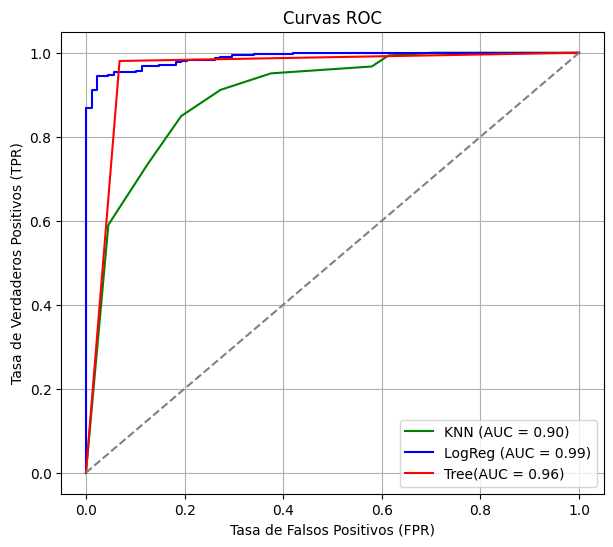

In [25]:
# cálculo de los elementos
# Curva ROC

fpr_test_knn, tpr_test_knn, _ = roc_curve(y_test, modelo_knn.predict_proba(X_test)[:,1])
fpr_test_log, tpr_test_log, _ = roc_curve(y_test, modelo_log.predict_proba(X_test)[:,1])
fpr_test_tree, tpr_test_tree, _ = roc_curve(y_test, modelo_tree.predict_proba(X_test)[:,1])

# AUC
auc_test_knn = roc_auc_score(y_test, modelo_knn.predict_proba(X_test)[:,1])
auc_test_log = roc_auc_score(y_test, modelo_log.predict_proba(X_test)[:,1])
auc_test_tree = roc_auc_score(y_test, modelo_tree.predict_proba(X_test)[:,1])

# Gráfica curva ROC
plt.figure(figsize=(7,6))
plt.plot(fpr_test_knn, tpr_test_knn, color='green', label=f'KNN (AUC = {auc_test_knn:.2f})')
plt.plot(fpr_test_log, tpr_test_log, color='blue', label=f'LogReg (AUC = {auc_test_log:.2f})')
plt.plot(fpr_test_tree, tpr_test_tree, color='red', label=f'Tree(AUC = {auc_test_tree:.2f})')

# Línea diagonal (azar)
plt.plot([0,1], [0,1], color='gray', linestyle='--')

# Detalles del gráfico
plt.xlabel("Tasa de Falsos Positivos (FPR)")
plt.ylabel("Tasa de Verdaderos Positivos (TPR)")
plt.title("Curvas ROC")
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

# <FONT SIZE=5 COLOR="purple"> 3. Validación Cruzada </FONT>

La **validación cruzada**, o *cross validation*, es una técnica utilizada para evaluar los resultados obtenidos de un modelo de *machine learning* y garantizar que son independientes de los conjuntos de entrenamiento ($X_{train}$) y prueba ($X_{test}$).

- Cuando usamos la función de *sklearn*:

$$train\_test\_split(X, y, random\_state = 123 )$$

se extraen dos muestras aleatorias como conjuntos de entrenamiento y prueba. Luego se hace el proceso de entrenamiento y validación del modelo, teniendo como referencias las muestras seleccionadas. Sin embargo, una pregunta natural es:


# <FONT SIZE=5 COLOR="purple"> 4. Búsqueda en Grilla </FONT>



Para hacer la búsqueda en grilla, vamos a considerar los siguientes parámetros

1. El número de vecinos $k$ : [1,20]
2. Las métricas : *euclideana* y *manhattan*
3. Los pesos: "uniformes" o basados en "distancia"

De acuerdo con lo anterior tenemos

$$(20 \, vecinos) \times ( 2 \, metricas) \times ( 2 \, pesos) = 80$$

combinaciones de parámetros.

**Tuning KNN**

In [26]:
from sklearn.pipeline import Pipeline

# Crear pipeline con escalador y modelo
pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("knn", KNeighborsClassifier())
])

# definimos los parámetros que vamos a combinar. Diccionario
grid_params = {"knn__n_neighbors" : list(range(1, 21)),         # se recorre la lista en k
               "knn__weights" : ["uniform","distance"],         # se establecen los pesos
               "knn__metric" : ["euclidean","manhattan"]}       # se establecen las métricas

# hacemos la búsqueda en grilla con 10-folds
Grid_Search = GridSearchCV(pipe,                                     # el modelo aplicado
                           grid_params,                             # los parámetros que van a variar
                           cv = 10,                                 # el número de folds
                           verbose = 3)                             # para que imprima resultados. Posibilidades: 1,2 o 3
# Entrenar el modelo obtenido arriba
g_res_knn = Grid_Search.fit(X_train,y_train)

Fitting 10 folds for each of 80 candidates, totalling 800 fits
[CV 1/10] END knn__metric=euclidean, knn__n_neighbors=1, knn__weights=uniform;, score=0.870 total time=   0.0s
[CV 2/10] END knn__metric=euclidean, knn__n_neighbors=1, knn__weights=uniform;, score=0.859 total time=   0.0s
[CV 3/10] END knn__metric=euclidean, knn__n_neighbors=1, knn__weights=uniform;, score=0.793 total time=   0.0s
[CV 4/10] END knn__metric=euclidean, knn__n_neighbors=1, knn__weights=uniform;, score=0.935 total time=   0.0s
[CV 5/10] END knn__metric=euclidean, knn__n_neighbors=1, knn__weights=uniform;, score=0.848 total time=   0.0s
[CV 6/10] END knn__metric=euclidean, knn__n_neighbors=1, knn__weights=uniform;, score=0.859 total time=   0.0s
[CV 7/10] END knn__metric=euclidean, knn__n_neighbors=1, knn__weights=uniform;, score=0.848 total time=   0.0s
[CV 8/10] END knn__metric=euclidean, knn__n_neighbors=1, knn__weights=uniform;, score=0.868 total time=   0.0s
[CV 9/10] END knn__metric=euclidean, knn__n_neigh

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


[CV 2/10] END knn__metric=manhattan, knn__n_neighbors=4, knn__weights=uniform;, score=0.935 total time=   0.1s
[CV 3/10] END knn__metric=manhattan, knn__n_neighbors=4, knn__weights=uniform;, score=0.837 total time=   0.0s
[CV 4/10] END knn__metric=manhattan, knn__n_neighbors=4, knn__weights=uniform;, score=0.924 total time=   0.1s
[CV 5/10] END knn__metric=manhattan, knn__n_neighbors=4, knn__weights=uniform;, score=0.891 total time=   0.0s
[CV 6/10] END knn__metric=manhattan, knn__n_neighbors=4, knn__weights=uniform;, score=0.891 total time=   0.0s
[CV 7/10] END knn__metric=manhattan, knn__n_neighbors=4, knn__weights=uniform;, score=0.924 total time=   0.0s
[CV 8/10] END knn__metric=manhattan, knn__n_neighbors=4, knn__weights=uniform;, score=0.945 total time=   0.0s
[CV 9/10] END knn__metric=manhattan, knn__n_neighbors=4, knn__weights=uniform;, score=0.868 total time=   0.0s
[CV 10/10] END knn__metric=manhattan, knn__n_neighbors=4, knn__weights=uniform;, score=0.956 total time=   0.0s


Ahora, buscamos el mejor *score*

In [27]:
print("Mejor score: ",g_res_knn.best_score_)

Mejor score:  0.918227424749164


Finalmente, los hiperparámetros que lograron ese *score*

In [28]:
print("Mejores hiperparámetros", g_res_knn.best_params_)

Mejores hiperparámetros {'knn__metric': 'manhattan', 'knn__n_neighbors': 11, 'knn__weights': 'distance'}


**Tuning Regresión Logística**

In [31]:
# Crear pipeline con escalador y modelo
pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("logreg", LogisticRegression(max_iter=1000))
])

# Definir los hiperparámetros a probar
grid_params = {
    "logreg__penalty": ["l1", "l2", "elasticnet", None],     # tipo de regularización
    "logreg__C": [0.001, 0.01, 0.1, 1, 10, 100],             # fuerza de regularización (inversa de lambda)
}

# Crear búsqueda en grilla
Grid_Search = GridSearchCV(
    pipe,
    grid_params,
    cv=10,
    verbose=3,
)

# Entrenar el modelo
g_res_logreg = Grid_Search.fit(X_train, y_train)

# Resultados
print("Mejores parámetros:", g_res_logreg.best_params_)
print("Mejor puntuación (CV):", g_res_logreg.best_score_)

Fitting 10 folds for each of 24 candidates, totalling 240 fits
[CV 1/10] END logreg__C=0.001, logreg__penalty=l1;, score=nan total time=   0.0s
[CV 2/10] END logreg__C=0.001, logreg__penalty=l1;, score=nan total time=   0.0s
[CV 3/10] END logreg__C=0.001, logreg__penalty=l1;, score=nan total time=   0.0s
[CV 4/10] END logreg__C=0.001, logreg__penalty=l1;, score=nan total time=   0.0s
[CV 5/10] END logreg__C=0.001, logreg__penalty=l1;, score=nan total time=   0.0s
[CV 6/10] END logreg__C=0.001, logreg__penalty=l1;, score=nan total time=   0.0s
[CV 7/10] END logreg__C=0.001, logreg__penalty=l1;, score=nan total time=   0.0s
[CV 8/10] END logreg__C=0.001, logreg__penalty=l1;, score=nan total time=   0.0s
[CV 9/10] END logreg__C=0.001, logreg__penalty=l1;, score=nan total time=   0.0s
[CV 10/10] END logreg__C=0.001, logreg__penalty=l1;, score=nan total time=   0.0s
[CV 1/10] END logreg__C=0.001, logreg__penalty=l2;, score=0.783 total time=   0.0s
[CV 2/10] END logreg__C=0.001, logreg__pena

**Tuning Árboles de Decisión**

In [30]:
# Pipeline (sin escalado; para mantener estructura puedes usar 'passthrough')
pipe = Pipeline([
    ("model", DecisionTreeClassifier(random_state=42))
])

# Hiperparámetros importantes del árbol
grid_params = {
    "model__criterion": ["gini", "entropy", "log_loss"],   # función de impureza
    "model__max_depth": [None, 3, 5, 7, 10, 15, 20],       # control de complejidad
    "model__min_samples_split": [2, 5, 10, 20],            # mínimo para dividir nodo
}

Grid_Search = GridSearchCV(
    pipe,
    grid_params,
    cv=10,
    verbose=3,
    n_jobs=-1
)

g_res_tree = Grid_Search.fit(X_train, y_train)

print("Mejores parámetros:", g_res_tree.best_params_)
print("Mejor puntuación (CV):", g_res_tree.best_score_)

Fitting 10 folds for each of 84 candidates, totalling 840 fits
Mejores parámetros: {'model__criterion': 'entropy', 'model__max_depth': 3, 'model__min_samples_split': 2}
Mejor puntuación (CV): 0.9847109412326803
